### Transformer training pipeline

Dataset

↓

Tokenization

↓

Vocabulary creation

↓

Encoding sentences → numbers

↓

Padding

↓

Transformer model(Encoder+Decoder)

↓

Loss (CrossEntropy)

↓

Training loop

↓

Prediction

In [1]:
# step-1 install libraries 
import torch
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset     # load_dataset is a function from Hugging Face's datasets library. Its job is to load datasets from various sources.
from torch.nn.utils.rnn import pad_sequence
import math
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# step-2 Load HuggingFace dataset
 
# It's a dataset identifier with two parts:
# First part (opus_books): The dataset name/collection
# Second part (en-fr): The specific language pair (English→French)

# Load the "opus_books" dataset for English-French translation
# "opus_books" is a collection of book translations
# "en-fr" means English-French language pair

dataset = load_dataset("opus_books", "en-fr")
# This creates a DatasetDict with 'train' split containing English-French sentence pairs
# Each example looks like: {'translation': {'en': 'Hello', 'fr': 'Bonjour'}}
# dataset is a Dictionary with keys: ["train"]

# Take only first 5000 examples from training set (to keep things manageable)
# .select(range(5000)) picks rows with indices 0 to 4999

data = dataset["train"].select(range(5000))
#      ↑            ↑      ↑
#      |            |      └── Take first 5000 rows
#      |            └── Access the 'train' split
#      └── DatasetDict containing all splits
# Now 'data' has 5000 examples instead of the full dataset (which could be lakhs)

# Extract English sentences from each example
# [x["translation"]["en"] for x in data] means:
# For each item 'x' in 'data', go to x["translation"] then get ["en"] value
# .lower() converts all text to lowercase (for consistency)
input = [x["translation"]["en"].lower() for x in data]
#        ↑  ↑            ↑
#        |  |            └── Get 'en' (English) from translation
#        |  └── Get 'translation' dictionary from the row
#        └── Each item 'x' is one row from data

# Result: List of English sentences like ["hello", "how are you", "the cat", ...]

# Extract French translations similarly
# Same process but get ["fr"] value instead of "en"
targets = [x["translation"]["fr"].lower() for x in data]
# Result: List of French sentences like ["bonjour", "comment allez-vous", "le chat", ...]



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

en-fr/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/127085 [00:00<?, ? examples/s]

In [3]:
print(dataset)
first=dataset["train"][1]
print(first)

DatasetDict({
    train: Dataset({
        features: ['id', 'translation'],
        num_rows: 127085
    })
})
{'id': '1', 'translation': {'en': 'Alain-Fournier', 'fr': 'Alain-Fournier'}}


In [4]:
# step-3 Build Vocabulary

# Define a function that creates a word-to-number mapping from sentences
def build_vocab(sentences):
    
    # Initialize vocabulary with 3 special tokens:
    # <pad> (0): Used to make all sentences same length by padding
    # <start> (1): Marks beginning of sentence for decoder
    # <end> (2): Marks end of sentence for decoder
    
    vocab = {"<pad>": 0, "<start>": 1, "<end>": 2}
    
    # Start numbering new words from index 3 (since 0,1,2 are taken)
    idx = 3
    
    # Loop through each sentence in our list
    for sent in sentences:
        # Split sentence into individual words (by spaces)
        for word in sent.split():
            # If this word is not already in vocabulary
            if word not in vocab:
                # Add word to vocabulary with current index number
                vocab[word] = idx
                # Increment index for next new word
                idx += 1
    
    # Return the complete vocabulary dictionary
    return vocab

# Build vocabulary for English sentences (source language)
# input = list of English sentences

eng_vocab = build_vocab(input)
# Result: {"<pad>":0, "<start>":1, "<end>":2, "hello":3, "world":4, ...}
# Build vocabulary for French sentences (target language)
# targets = list of French sentences

tgt_vocab = build_vocab(targets)
# Result: {"<pad>":0, "<start>":1, "<end>":2, "bonjour":3, "monde":4, ...}
# Create reverse vocabulary for English (number → word)
# This swaps keys and values from eng_vocab

eng_inv = {v: k for k, v in eng_vocab.items()}
# Result: {0:"<pad>", 1:"<start>", 2:"<end>", 3:"hello", 4:"world", ...}
# .items() gives you pairs, v:k swaps them - so numbers become keys and words become values!
# Create reverse vocabulary for French (number → word)

tgt_inv = {v: k for k, v in tgt_vocab.items()}
# Result: {0:"<pad>", 1:"<start>", 2:"<end>", 3:"bonjour", 4:"monde", ...}

# Get vocabulary sizes (number of unique words including special tokens)
eng_vocab_size = len(eng_vocab)  # Used for embedding layer dimensions
tgt_vocab_size = len(tgt_vocab)  # Used for output layer dimensions

In [5]:
# step-4  represent word to numbers 

def encode(sentence,vocab):
    
# Takes a sentence (like "hello world") and vocabulary dictionary
# Returns a tensor (list of numbers) representing the sentence

   return torch.tensor([vocab[x] for x in sentence.split() if x in vocab])
   # 1. sentence.split() → ["hello", "world"]
   # 2. vocab[w] for each word → [3, 4] (if hello=3, world=4 in vocab)
   # 3. torch.tensor() → converts to PyTorch tensor
   
eng_data=[encode(s,eng_vocab) for s in input]
# For each English sentence in 'inputs', convert to numbers
# Result: List of tensors, one per sentence
# After encoding:
#src_data = [
    #tensor([3, 4]),        # "hello world"
    #tensor([5, 6, 7])      # "how are you"]

tgt_input = []   # Will store decoder INPUT sequences (with <start>)
tgt_output = []  # Will store decoder OUTPUT sequences (with <end>)

french_tokens=[encode(s,tgt_vocab) for s in targets]
# Result: List of tensors like [tensor([3,4]), tensor([5,6,7,8]), ...]
# Example: "bonjour monde" → tensor([3,4])

for tokens in french_tokens:
    
    tgt_input.append(torch.cat([torch.tensor([tgt_vocab["<start>"]]), tokens]))
    # tokens is already a tensor from encode() function
    # Decoder input: <start> + tokens
    # torch.cat() joins tensors together
    # cat = concatenate (join/combine) tensors together
    #a = torch.tensor([1, 2, 3])
    #b = torch.tensor([4, 5, 6])
    #c = torch.cat([a, b])
    #print(c)  # tensor([1, 2, 3, 4, 5, 6])
    # Just puts them one after another
    
    tgt_output.append(torch.cat([tokens, torch.tensor([tgt_vocab["<end>"]])]))
    # Decoder output: tokens + <end>
    # Result: tensor([3, 4, 2]) for "bonjour monde"
    


### simple note 1:

French sentence: "bonjour monde"

                          ↓

                   tokens = [3, 4]

                    ↓              ↓

        tgt_input = [1, 3, 4]    tgt_output = [3, 4, 2]

        (to decoder)              (what decoder should predict)

Position:    1       2       3

Input:     <start>  bonjour  monde

Target:    bonjour  monde    <end>

In [6]:
# step-5 Padding

from torch.nn.utils.rnn import pad_sequence

# pad_sequence-A PyTorch function that takes a list of tensors of different lengths and pads them to all have the same length.
# Takes list of tensors of different lengths
# Returns a single tensor with all sequences padded to same length

eng_pad = pad_sequence(eng_data,batch_first=True,padding_value=0)
tgt_in_pad = pad_sequence(tgt_input,batch_first=True,padding_value=0)
tgt_out_pad = pad_sequence(tgt_output,batch_first=True,padding_value=0)

# Your data
# tgt_input = [
    # tensor([1, 3, 4]),        # "<start> bonjour monde" (len 3)
    # tensor([1, 5, 6, 7])      # "<start> comment allez vous" (len 4)

# pad_sequence finds max_len = 4
# tgt_in_pad = pad_sequence(tgt_input, batch_first=True, padding_value=0)

# Result:
# [
#     [1, 3, 4, 0],    # padded with 0 at the end
#     [1, 5, 6, 7]     # unchanged
# ]

# result = pad_sequence(sequences, batch_first=True, padding_value=0)

# Without batch_first: shape [max_len, batch_size]
# [
#     [3, 5, 8],
#     [4, 6, 9],
#     [0, 7, 10],
#     [0, 0, 11]
# ]

# With batch_first=True: shape [batch_size, max_len] (easier to work with)
# [
#     [3, 4, 0, 0],
#     [5, 6, 7, 0],
#     [8, 9, 10, 11]
# ]

print(eng_pad.shape)
print(tgt_in_pad.shape)
print(tgt_out_pad.shape)

torch.Size([5000, 200])
torch.Size([5000, 120])
torch.Size([5000, 120])


In [7]:
# step-6 Position embedding

class PositionalEncoding(nn.Module):
    # This class adds position information to word embeddings
    # Because transformers process all words in parallel and don't know word order
    # Inherits from nn.Module (PyTorch's base class)
    
    
    def __init__(self, d_model, max_len=500):
        
        # CONSTRUCTOR METHOD
        # __init__ is the CONSTRUCTOR - it runs ONCE when creating a new object
        # It sets up all the LAYERS and PARAMETERS that this block will use
        
        super().__init__()   # Call parent class (nn.Module) constructor
        # d_model = embedding dimension (e.g., 8, 512)
        # max_len = maximum sentence length we'll ever see (default 500) 
    
        pe = torch.zeros(max_len,d_model) # Shape: [10, 6]   
        # Position 1: [0, 0, 0, 0, 0, 0]
        # Position 2: [0, 0, 0, 0, 0, 0]
        # ...
        # Position 10:[0, 0, 0, 0, 0, 0]

        
        pos = torch.arange(0,max_len).unsqueeze(1)
        # torch.arange(0,10) → [0,1,2,3,4,5,6,7,8,9] a list
        # unsqueeze(1) → [[0],[1],[2],...[9]]  Shape: [max_len,1]  
        # unsqueeze(1)**: Reshapes the vector from a 1D array to a 2D column matrix (Shape: `[max_len, 1]`).   
        
        div = torch.exp(torch.arange(0,d_model,2)*(-math.log(10000)/d_model)) 
        # PE(pos, 2i) = sin(pos / 10000^(2i / d_model))
        # PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))

        # 1/10000^(2i/d_model)  = 10000^(-2i/d_model)
                      # = exp(log(10000^(-2i/d_model)))
                      # = exp(-2i/d_model × log(10000))
                      # = exp(2i × (-log(10000)/d_model))
                      # 2i is exactly torch.arange(0, d_model, 2)  [0,2,4...]   when i=0, 2i=0 ;  i=1, 2i=2 .....
        
    
        pe[:, 0::2] = torch.sin(pos * div)  # Even columns get sine
        
        # position * div_term: [10,1] × [1,3] broadcasts to [10,3]
        # sin() applied to each element

        pe[:,1::2]=torch.cos(pos*div)
        # Fill odd columns (1,3,5) with cosine
        # pe[:, 1::2] means: ALL rows (:), columns starting at 1, step 2 (1,3,5)
        # Same position * div_term but with cos()
        
    
        self.pe = pe.unsqueeze(0)
        
        #Before unsqueeze(0):
        #pe = torch.zeros(10, 6)  # Shape: [10, 6] - 10 positions, 6 features
        # [pos1: [0,0,0,0,0,0]
        #  pos2: [0,0,0,0,0,0]
        #  ...
        #  pos10:[0,0,0,0,0,0]]

        #After unsqueeze(0):
        #self.pe = pe.unsqueeze(0)  # Shape: [1, 10, 6]
        # Adds batch dimension at front
    
    def forward(self,x):
        
        # FORWARD METHOD 
        # forward defines what happens when data PASSES THROUGH this block
        # model = PositionalEncoding(d_model=8)  # Create instance
        # When we do this:
        # x_with_pos = model(x)  # ← This calls forward() automatically!
        
        x=x+self.pe[:,:x.size(1)].to(device)
        
        # Input x shape: [2, 3, 6]  (batch=2 sentences, 3 words each, 6 features)
        #x.size(1)  # = 3 (sequence length)

        # self.pe shape: [1, 10, 6]
        # self.pe[:, :3]  # Take first 3 positions from all batches
        
        return x



In [8]:
# step-7 Transformer Model

class Transformer(nn.Module):
    # This class combines ALL components into one complete Transformer model
    # It handles: Embedding + Position + Transformer layers + Output prediction
    
    def __init__(self):
        
        super().__init__()  # Initialize the parent nn.Module class
        d_model=64
        
        # make static embedding of the words
        self.eng_embed=nn.Embedding(eng_vocab_size,d_model)
        # English embedding layer: converts word indices to vectors
        # Input: word index (e.g., 3 for "hello")
        # Output: 128-dim vector representing that word
        # Example: tensor(3) → [0.2, -0.5, 0.7, ...] (128 numbers)
        
        self.tgt_embed=nn.Embedding(tgt_vocab_size,d_model)
        # Maps French word indices to 128-dim vectors
        
        # now add positional embedding
        self.pos=PositionalEncoding(d_model)
        # Adds position information to embeddings
        # Because transformer processes all words in parallel and needs to know word order
        # Example: "I love cats" - each word knows if it's 1st, 2nd, or 3rd word
        
        self.transformer=nn.Transformer(
            
        d_model=d_model,
        nhead=4,                 # 4 attention heads (parallel attention mechanisms)
        num_encoder_layers=3,    # 6 encoder blocks stacked
        num_decoder_layers=3,
        dim_feedforward=256,     # FFN inner dimension (expands 128→512→128)
        dropout=0.1, 
        batch_first=True         # Input shape: [batch, seq_len, features
        
        ) 
        
        self.fc=nn.Linear(d_model,tgt_vocab_size)
        # It's final linear layer where linear--> softmax--->Output probability 
        # Linear layer: 128 → vocabulary size (e.g., 5000 French words)
        # Converts final decoder output to probability scores for each French word
        # Example: [128-dim vector] → [score for each of 5000 possible French words]
        # fc ──→ [batch, tgt_len, tgt_vocab_size] (scores for each French word)
        
    def forward(self,eng,tgt):
        # eng: English sentences (source) - shape: [batch_size, eng_len]
        # tgt: French sentences (target) - shape: [batch_size, tgt_len]
        # Example: eng = [[3,45,67,12]] (1 sentence, 4 English words)
        # tgt = [[1,34,78,23]] (1 sentence, 4 French words with <start>)
        
        eng=self.pos(self.eng_embed(eng))
        # This does TWO things in one line (right to left):
        # 1. self.eng_embed(eng) - Convert word indices to vectors
        #    Input: [2,4] → Output: [2,4,128] (words → 128-dim vectors)
        # 2. self.pos(...) - Add position information
        #    Input: [2,4,128] → Output: [2,4,128] (same shape, now with position)
        
        tgt=self.pos(self.tgt_embed(tgt))
        
        tgt_mask=self.transformer.generate_square_subsequent_mask(tgt.size(1)).to(device)
        # tgt.size(1) = 4 (sequence length of target)
        # Creates a causal mask for decoder to prevent looking at future words
        # For 4 words, mask looks like:
        # [[0, -inf, -inf, -inf],   # Word1 can't see words 2,3,4
        #  [0, 0, -inf, -inf],      # Word2 can't see words 3,4
        #  [0, 0, 0, -inf],         # Word3 can't see word 4
        #  [0, 0, 0, 0]]            # Word4 can see all
        
        out = self.transformer(eng,tgt,tgt_mask=tgt_mask)
        # Parameters:
        # - eng: source (English) after embedding+pos [2,4,128]
        # - tgt: target (French) after embedding+pos [2,4,128]
        # - tgt_mask: prevents looking at future words

        # What transformer does internally:
        # 1. Encoder processes English: self-attention among English words
        # 2. Decoder processes French with:
        #    - Masked self-attention (can't see future)
        #    - Cross-attention (looks at encoder outputs)
        #    - Feed-forward network
        # Output shape: [2,4,128] (same as input shape)
        
        out = self.fc(out)
        # Input: [2,4,128] - 128-dim vectors for each word
        # Output: [2,4,5000] - scores for each of 5000 French words

        # For each word position, we get probability distribution over all French words
        
        return out
        # Returns shape [batch_size, tgt_len, tgt_vocab_size]


model = Transformer().to(device)
# This calls the __init__ method we defined earlier
# Now model contains:
# - eng_embed layer (5000 → 128)
# - tgt_embed layer (5200 → 128)
# - pos encoding layer
# - transformer with 6+6 layers, 4 heads
# - fc layer (128 → 5200)
# All weights are randomly initialized
    
        
        
        
        

### Transformer architecture flow:

eng [2,4,128] ──► ENCODER STACK (6 layers)

                  │
                  ▼

            ┌─────────────────┐
             
              Encoder Layer 1 
            
              • Self-Attn 
            
         
              • Add & Norm
         
              • FFN   
                   
              • Add & Norm 
              
            └─────────────────┘

                  │
                  ▼

            ┌─────────────────┐
            │ 
               Encoder Layer 2
            │
            │      ...        │
            └─────────────────┘

                  │
                  ▼

            ┌─────────────────┐
            │ Encoder Layer 6 │
            └─────────────────┘

                  │
                  ▼ encoder_output [2,4,128]

                  │

tgt [2,4,128] ──► DECODER STACK (6 layers)

                  │
                  ▼
            ┌─────────────────┐
              Decoder Layer 1 
             
              • Masked Self- 
                Attn    
                 
              • Add & Norm
               
              • Cross-Attn ───── encoder_output

              • Add & Norm 
              
              • FFN    
                  
              • Add & Norm 
              
            └─────────────────┘

                  │
                  ▼

            ┌─────────────────┐
            │ Decoder Layer 2 │
            │      ...        │
            └─────────────────┘

                  │
                  ▼

            ┌─────────────────┐
            │ Decoder Layer 6 │
            └─────────────────┘

                  │
                  ▼

         out [2,4,128]

         Decoder Stack (6 layers) 

                   ↓

[2, 4, 128]  ← Contextualized French word vectors

                   ↓

   FC Layer (nn.Linear(128, 5000))

                   ↓

[2, 4, 5000]  ← Raw scores (logits) for each French word

                   ↓

   Softmax (applied during loss calculation)

                   ↓

[2, 4, 5000]  ← Probabilities (sum to 1 for each position)


In [9]:
# step-8 Training setup

criterion=nn.CrossEntropyLoss(ignore_index=0)
# Creates loss function that will measure how wrong predictions are

# For one position:
# predicted_scores = [2.1, 5.3, 1.2, 8.7, ...]  # 5000 scores
# actual_word = 3  # Target word index (e.g., "bonjour")
# loss = criterion(predicted_scores, actual_word)
# = -log(probability of correct word)
# If model is confident (0.9 prob) → loss ≈ 0.1
# If model is wrong (0.1 prob) → loss ≈ 2.3

# ignore_index=0  # Tells loss to ignore padding tokens (index 0)
# Example target sequence: [3, 45, 78, 0, 0]  (padded with zeros)
# Loss will ONLY be calculated for positions 0,1,2 (actual words)
# Positions with 0 (padding) are ignored - no loss contribution

optimizer = optim.Adam(model.parameters(),lr=0.0005,weight_decay=1e-5)
# Creates optimizer that will update model weights during training
# During training:
# optimizer.zero_grad()     # Clear old gradients
# loss.backward()           # Compute new gradients
# optimizer.step()          # Update weights using gradients

# lr=0.0005 (learning rate) controls how big each update is
# Too high: unstable training
# Too low:  very slow learning
# 0.0005 is typical for Adam optimizer

# model.parameters() includes:
# All learnable weights in the model:
#- eng_embed.weight      # [5000, 128]
#- tgt_embed.weight      # [5200, 128]
#- transformer.encoder weights (6 layers × many parameters)
#- transformer.decoder weights (6 layers × many parameters)
#- fc.weight and bias    # [5000, 128] + [5000]
# Total: millions of parameters!


eng_pad = eng_pad.to(device)    # Move English input to GPU/CPU
tgt_in_pad = tgt_in_pad.to(device)  # Everything must be on SAME device!
tgt_out_pad = tgt_out_pad.to(device)

Epoch 0 finished - Average Loss: 7.8888
Epoch 1 finished - Average Loss: 6.9919
Epoch 2 finished - Average Loss: 6.7785
Epoch 3 finished - Average Loss: 6.5436
Epoch 4 finished - Average Loss: 6.3190
Epoch 5 finished - Average Loss: 6.1185
Epoch 6 finished - Average Loss: 5.9423
Epoch 7 finished - Average Loss: 5.7807
Epoch 8 finished - Average Loss: 5.6337
Epoch 9 finished - Average Loss: 5.4924
✅ Learning rate reduced from 0.0005 to 0.0001
Epoch 10 finished - Average Loss: 5.3565
Epoch 11 finished - Average Loss: 5.1876
Epoch 12 finished - Average Loss: 5.1556
Epoch 13 finished - Average Loss: 5.1261
Epoch 14 finished - Average Loss: 5.0976
Epoch 15 finished - Average Loss: 5.0666
Epoch 16 finished - Average Loss: 5.0416
Epoch 17 finished - Average Loss: 5.0123
Epoch 18 finished - Average Loss: 4.9894
Epoch 19 finished - Average Loss: 4.9622
Epoch 20 finished - Average Loss: 4.9366
Epoch 21 finished - Average Loss: 4.9112
Epoch 22 finished - Average Loss: 4.8881
Epoch 23 finished - A

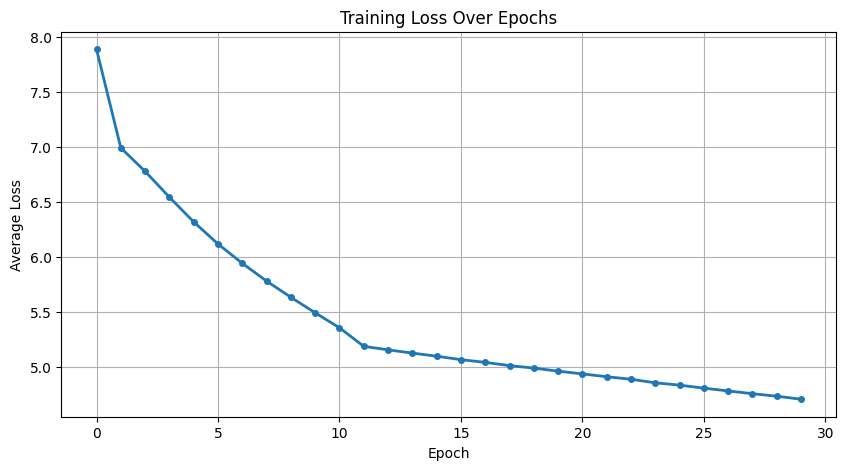

In [10]:
# step-9 Training loop
# ============================================================

# Import necessary PyTorch utilities for batching
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
# TensorDataset: Wraps tensors into a dataset where each sample is a tuple
# DataLoader: Handles batching, shuffling, and parallel data loading

# ==================== CREATE DATASET ====================
# Wrap all padded tensors into a single dataset object
# Each sample will be (eng_pad[i], tgt_in_pad[i], tgt_out_pad[i])
train_dataset = TensorDataset(eng_pad, tgt_in_pad, tgt_out_pad)
# eng_pad: padded English sentences [127085, max_src_len]
# tgt_in_pad: padded decoder input with <start> [127085, max_tgt_len]
# tgt_out_pad: padded target output with <end> [127085, max_tgt_len]

# ==================== CREATE DATALOADER ====================
# DataLoader splits dataset into batches and manages iteration
train_loader = DataLoader(
    train_dataset,      # Dataset to load from
    batch_size=32,      # Process 32 sentences at a time (fits in GPU memory)
    shuffle=True        # Shuffle data every epoch (prevents order bias)
)
# Now train_loader will yield batches of 32 samples each

losses = []  # List to store average loss per epoch

#  TRAINING LOOP 
epochs = 30  # Number of complete passes through entire dataset

for epoch in range(epochs):  # For each epoch (0,1,2,3,4)
    epoch_loss = 0  # Initialize total loss for this epoch
    batch_count = 0  # Count batches processed
    # Inner loop: iterate through ALL batches in the dataset
    for batch_eng, batch_tgt_in, batch_tgt_out in train_loader:
        # Each batch contains:
        # batch_eng: [32, max_src_len] - English sentences
        # batch_tgt_in: [32, max_tgt_len] - Decoder input with <start>
        # batch_tgt_out: [32, max_tgt_len] - Target output with <end>
        
        # ==================== MOVE BATCH TO GPU ====================
        # All tensors must be on same device as model
        batch_eng = batch_eng.to(device)           # Move English batch to GPU
        batch_tgt_in = batch_tgt_in.to(device)     # Move decoder input to GPU
        batch_tgt_out = batch_tgt_out.to(device)   # Move target output to GPU
        
        # ==================== FORWARD PASS ====================
        optimizer.zero_grad()  # Clear gradients from previous batch
        
        # Pass batch through model
        # model: Transformer(eng_embed, tgt_embed, pos, transformer, fc)
        output = model(batch_eng, batch_tgt_in)
        # output shape: [32, max_tgt_len, tgt_vocab_size]
        # Raw scores (logits) for each position and each possible French word
        
        # ==================== LOSS CALCULATION ====================
        # Reshape for CrossEntropyLoss
        # output.reshape(-1, tgt_vocab_size): [32*max_tgt_len, 5000]
        # batch_tgt_out.reshape(-1): [32*max_tgt_len]
        loss = criterion(
            output.reshape(-1, tgt_vocab_size),  # Flatten all positions
            batch_tgt_out.reshape(-1)             # Flatten all targets
        )
        # For each of (32×seq_len) positions:
        # 1. Take 5000 scores for that position
        # 2. Apply softmax to get probabilities
        # 3. Compare probability of correct word index
        # 4. Average all losses
        
        # ==================== BACKWARD PASS ====================
        loss.backward()  # Compute gradients for ALL model parameters
        # Gradients tell each weight "how much did you contribute to error?"
        
        # ==================== UPDATE WEIGHTS ====================
        optimizer.step()  # Update model weights using gradients
        # New_weight = old_weight - learning_rate × gradient
        # This is where actual learning happens!
        
        epoch_loss += loss.item()  # Add current batch loss to epoch total
        batch_count += 1
         # Reduce learning rate after epoch 10
    if epoch == 10:  # After 10th epoch
        for param_group in optimizer.param_groups:
            old_lr = param_group['lr']
            param_group['lr'] = 0.0001  # Reduce to 0.0001
            print(f"✅ Learning rate reduced from {old_lr} to {param_group['lr']}")
    
    #  CALCULATE AVERAGE LOSS FOR EPOCH ====================
    avg_epoch_loss = epoch_loss / batch_count
    losses.append(avg_epoch_loss)  # Store average loss for this epoch
    
    # Print progress
    print(f"Epoch {epoch} finished - Average Loss: {avg_epoch_loss:.4f}")

#  PLOT LOSS AFTER TRAINING 
print("\nTraining complete! Plotting loss curve...")
plt.figure(figsize=(10, 5))
plt.plot(losses, marker='o', linestyle='-', linewidth=2, markersize=4)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Training Loss Over Epochs')
plt.grid(True)
plt.show()
    
# Example with 127,085 sentences, batch_size=32:
# - Total batches per epoch = 127,085 / 32 ≈ 3,972 batches
# - Each epoch processes ALL 3,972 batches
# - Model weights updated 3,972 times per epoch
# - After 5 epochs: model has seen each sentence 5 times,
#   and weights updated ~19,860 times!
    
    

    # Before Reshape (Original Shapes):
    #output.shape      = [2, 4, 5000]  # 2 sentences, 4 words each, 5000 scores per word
    #tgt_out_pad.shape = [2, 4]        # 2 sentences, 4 words each (correct word indices)
    # after:
    # output.reshape(-1, 5000)  # [8, 5000]  (2×4 = 8 positions total)
    # tgt_out_pad.reshape(-1)   # [8]        (8 correct word indices)
    
    # For each position, CrossEntropyLoss does:
    # 1. Takes the 5000 scores for that position
    # 2. Applies softmax to get probabilities
    # 3. Compares probability of correct word index

    
    #loss.backward()    # Computes gradients for ALL model parameters
    
    # optimizer.step()    
    # Updates all model weights using computed gradients
    # New_weight = old_weight - learning_rate × gradient
    # This is where actual learning happens!
    
    


In [ ]:
# step-10 prediction(inference)

def translate(sentence,temperature=0.8):
    
    model.eval()    # model.eval() = "Stop training behaviors, start inference behaviors"
    
    eng = encode(sentence.lower(),eng_vocab).unsqueeze(0).to(device)
    # 1. encode(sentence.lower(), src_vocab) → convert words to indices
    # Example: "hello world" → tensor([3, 4])
    
    tgt = torch.tensor([[tgt_vocab["<start>"]]]).to(device)
    # Start with just the <start> token
    # Shape: [1,1]  (batch=1, sequence length=1)
    # Example: [[1]] where 1 is <start> token
    generated = []
    for i in range(20):       # Maximum 20 words (prevent infinite loop)
        
        out = model(eng,tgt)
        # Forward pass through entire model
        # eng: English sentence [1, src_len]
        # tgt: Current French sequence [1, current_len]
        # out shape: [1, current_len, tgt_vocab_size]
        
        # Starting: tgt = [[1]]  # Just <start>
        # current_len = 1

        # out = model(src, tgt)  # out shape: [1, 1, 5000]
        #                      #         batch=1, current_len=1, vocab=5000

        # After 1st prediction: tgt = [[1, 3]]  # <start>, bonjour
        # current_len = 2
        # out = model(src, tgt)  # out shape: [1, 2, 5000]
        #                      #         batch=1, current_len=2, vocab=5000
        # After 2nd prediction: tgt = [[1, 3, 4]]  # <start>, bonjour, monde
        # current_len = 3

        # out = model(src, tgt)  # out shape: [1, 3, 5000]
        #                      #         batch=1, current_len=3, vocab=5000
        
        # Apply temperature to logits
        # Apply repetition penalty
        for token in generated:
            logits[0, token] /= repeat_penalty
        logits = out[:, -1, :] / temperature
        probs = F.softmax(logits, dim=-1)
        
        # Sample instead of argmax
        next_token = torch.multinomial(probs, 1).item()
        
        #next_token = out[:,-1].argmax(dim=-1).item()
        #out[:, -1] → take ONLY the LAST position's predictions [1, 5000]
        # argmax(dim=-1) → find index with highest score for next word index finding
        # .item() → convert tensor to Python number
        # Example: if "bonjour" (index 3) has highest score, next_token = 3
        # FORCE STOP if sequence is getting too long
        
        
        tgt = torch.cat(
            [tgt,torch.tensor([[next_token]]).to(device)],
            dim=1
        )
        generated.append(next_token)
        # Concatenate new token to existing sequence
        # Before: tgt = [[1, 3]]     (<start>, bonjour)
        # New token: [[4]]            (monde)
        # After:  tgt = [[1, 3, 4]]  (<start>, bonjour, monde)
        
        if next_token == tgt_vocab["<end>"]:
            break
    
    
    words = [tgt_inv[i] for i in tgt.squeeze().tolist()]
    
    # tgt.squeeze() → remove batch dimension [1, seq_len] → [seq_len]
    # .tolist() → convert tensor to Python list [1,3,4,2]
    # tgt_inv[i] → look up each index in reverse vocabulary
    # Example: [1,3,4,2] → ["<start>", "bonjour", "monde", "<end>"]
    
    
    return " ".join(words)

    # Join words with spaces
    # ["<start>", "bonjour", "monde", "<end>"] → "<start> bonjour monde <end>"

In [ ]:
# step-11 test prediction
print(translate("we are friends"))



<start> – vous vous vous vous vous vous vous vous vous vous vous vous vous vous vous vous vous vous vous
<start> vous vous vous vous vous vous vous vous vous vous vous vous vous vous vous vous vous vous vous vous
<start> vous vous vous vous vous vous vous vous vous vous vous vous vous vous vous vous vous vous vous vous



Time Step 1:

src: "hello world" (fixed) ──► Encoder ──► [enc_out1, 

enc_out2]
                                    
tgt: [start] 

      ↓

Prediction: "bonjour"

Time Step 2:

src: "hello world" (same) ────────► [enc_out1, enc_out2]

                                  
tgt: [start, bonjour] 

      ↓

Prediction: "monde"

Time Step 3:

src: "hello world" (same) ────────► 

[enc_out1, enc_out2]

                                   

tgt: [start, bonjour, monde] 

      ↓
      
Prediction: "end"

Step 1: First Forward Pass
python
# Starting: tgt = [[1]]  # <start> only
# Shape: [1, 1] (batch=1, current_len=1)

out = model(src, tgt)  # Forward pass

# out shape: [1, 1, 5]  
#            batch=1, current_len=1, vocab_size=5

# out contains scores for the ONE position we have:
out = tensor([[
    [2.1, 1.5, 0.3, 4.8, 1.2]   # Scores for position 1 (the only position)
    #  ↑    ↑    ↑    ↑    ↑
    # word0 word1 word2 word3 word4
]])
Step 2: Get next_token from this out
python
# out[:, -1] takes the last position (only position we have)
last_pos_scores = out[:, -1]  # = [2.1, 1.5, 0.3, 4.8, 1.2]
#                                                  ↑
#                                            highest score at index 3

# argmax finds index with highest score
next_token = last_pos_scores.argmax(dim=-1).item()  # = 3

# 3 corresponds to "bonjour" in vocabulary
Step 3: Append to Target
python
tgt = torch.cat([tgt, torch.tensor([[3]]).to(device)], dim=1)
# Before: tgt = [[1]]
# After:  tgt = [[1, 3]]  (<start>, bonjour)
# Shape: [1, 2] (now current_len=2)